# 1. Reproducibility Configuration

- ensures experimental reproducibility.
- *SEED = 42* used for Python, NumPy, and TensorFlow.
- helped to reduce randomness of dataset shuffling, weight initialization and augmentation operations during training phase.

In [ ]:
import os, random, numpy as np, tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Import Dependencies

- imported modules to support data preprocessing, model development, evaluation, and visualization.
- **TensorFlow / Keras** - implement and train the model
- **NumPy** - numerical computations
- **Matplotlib** and **Seaborn** - graphical representation and visualization


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os



## 3. Mount Google Drive

- *dataset* and *experiment files* stored in **Google Colab**
- this approach ease dataset management and a faster access during training and evaluation

&rarr; mount Google Drive to provide access to dataset, trained models for training and evaluation

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!unzip -qo "/content/drive/MyDrive/FER2013.zip" -d "/content/"

## 4. FER2013 Loading and Preprocessing

- *FER2013* dataset was loaded from **train** and **test** directories using the *TensorFlow/Keras* **ImageDataGenerator** utility.

- images resized to **48x48 grayscale** to match RS-Xception requirements.

- during training (train_datagen), pixel values were normalized in range [0, 1] (`rescale=1./255`)

- *data augmentation techniques* used: only `rotation range`
&rarr; create small variations to improve model robustness.

- for test dataset (`val_datagen`) - only normalization (`rescale=1./255`) applied to ensure the unbiased evaluation of the model

- training images (`train_gen`) were shuffled at each epoch, while test images (`val_gen`) were not shuffled.



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15
)

val_datagen = ImageDataGenerator(rescale=1./255)

TRAIN_PATH = '/content/FER2013/train'
VAL_PATH = '/content/FER2013/test'




train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=16,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=16,
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## 5. RSX_v1 Model Architecture

- The `RSX_v1` model represents an initial RS-Xception-based architecture developed as a baseline experiment for FER classification.

- The model combines **depthwise separable convolutions**, **squeeze-and-excitation (SE) attention**, and **residual SE blocks**, while using a simpler feature extraction structure compared to the final RSX_v2 model.

- **Model Overview:**
  - *Input shape*: 48 × 48 × 1 grayscale facial images
  - *Initial feature extraction*: Two separable convolution blocks with 32 and 64 filters, each followed by Batch Normalization and ReLU activation
  - *Attention mechanism*: An SE block applied after the initial feature extraction stage
  - *Feature extraction*: Three Residual SE blocks with filter sizes [128, 256, 512]
  - *Residual learning*: Shortcut connections are used inside the Residual SE blocks to preserve feature information and improve gradient flow
  - *Classifier*: Global Average Pooling followed by a Dense layer with 128 units, Dropout regularization, and a final Softmax output layer
  - *Output*: Probability distribution over the seven FER2013 emotion classes

In [ ]:
from tensorflow.keras import layers, models

# Separable Convolution Block (lightweight conv)
def SeparableConvBlock(x, filters, kernel_size=3, stride=1):
    x = layers.SeparableConv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def Residual_SE_Block(x, filters, kernel_size=3):
    shortcut = x

    # Main path
    x = layers.SeparableConv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # SE attention
    x = SE_Block(x)

    # Projection shortcut if channels mismatch
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Residual addition
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x


# Squeeze-and-Excitation Block (attention mechanism)
def SE_Block(inputs, ratio=8):
    filters = inputs.shape[-1]
    se = layers.GlobalAveragePooling2D()(inputs)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    x = layers.multiply([inputs, se])
    return x




# RS-Xception-based Full Model
def RS_Xception(input_shape=(48, 48, 1), num_classes=7):
    inputs = layers.Input(shape=input_shape)

    # Initial layers
    x = SeparableConvBlock(inputs, 32)
    x = SeparableConvBlock(x, 64)
    x = SE_Block(x)

    # Feature extraction blocks
    for filters in [128, 256, 512]:
      x = Residual_SE_Block(x, filters)

    # Classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Create and summarize the model
model = RS_Xception()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 48, 48,    │         73 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 48, 48,    │      2,400 │ re_lu[0][0]       │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_1[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 48, 48,    │          0 │ re_lu_1[0][0],    │
│                     │ 64)               │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 48, 48,    │      8,896 │ multiply[0][0]    │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ re_lu_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │      2,064 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      2,176 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │      8,320 │ multiply[0][0]    │
│                     │ 128)              │            │                 

 Total params: 514,600 (1.96 MB)

 Trainable params: 510,824 (1.95 MB)

 Non-trainable params: 3,776 (14.75 KB)

## 6. Compile the model

- Before training, the model was compiled by defining the *optimization strategy*, *loss function*, and *evaluation metrics*.

- **Adam** optimizer was selected due to its adaptive learning rate mechanism, which combines the advantages of momentum and adaptive gradient optimization.

- Initial **learning rate** of 0.001 - used to provide stable and efficient convergence during training.

- Loss function is **Categorical Cross-Entropy**, since task involve multi-class classification.

- **Accuracy** - used as the primary evaluation metric to monitor model performance throughout training and validation.

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Training Configuration and Callbacks

- before training, several strategies were employed to improve convergence, prevent overfitting and address class imbalance of FER2013 dataset.

- **Early Stopping** with `patience=20` monitors the validation loss and terminates training when no further improvement is observed. The best-performing model weights are automatically restored.

- **ReduceLROnPlateau** - decreases the learning rate when the validation loss stops improving, allowing the optimizer to perform finer parameter updates during later training stages.

- **Model Checkpoint** - saves the model that achieves the highest validation accuracy, ensuring that the best-performing version is preserved for evaluation and future deployment.

- **Class Weights** were computed automatically from the training dataset to compensate for class imbalance &rarr; assigns higher importance to underrepresented emotion classes during optimization.



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_decay = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5)

checkpoint = ModelCheckpoint(
    filepath='//content/drive/MyDrive/RSX_v1_best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))



## 8. Model Training

- RS-Xception model - trained using the FER2013 dataset for a maximum of **150 epochs**.

- During training, **class weights** were applied to reduce the impact of class imbalance and improve recognition performance for less-represented emotions (*e.g. disgust, surprise*).

- The model was evaluated on the test dataset after each epoch - allowing the monitoring of validation accuracy (`val_accuracy`) and validation loss (`loss`) throughout the training process.

- **Callbacks** (*Early stopping*, *learning rate scheduling*, and *model checkpointing*) were employed to improve convergence and preserve the best-performing model.

In [ ]:
EPOCHS = 150

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, lr_decay, checkpoint]
)



Epoch 1/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1786 - loss: 1.9430
Epoch 1: val_accuracy improved from None to 0.23628, saving model to //content/drive/MyDrive/RSX_v1_best_model.h5



Epoch 1: finished saving model to //content/drive/MyDrive/RSX_v1_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 89s 32ms/step - accuracy: 0.2031 - loss: 1.9299 - val_accuracy: 0.2363 - val_loss: 1.9033 - learning_rate: 0.0010
Epoch 2/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2174 - loss: 1.8981
Epoch 2: val_accuracy did not improve from 0.23628
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.2119 - loss: 1.9140 - val_accuracy: 0.2193 - val_loss: 1.8972 - learning_rate: 0.0010
Epoch 3/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2259 - loss: 1.9136
Epoch 3: val_accuracy improved from 0.23628 to 0.23767, saving model to //content/drive/MyDrive/RSX_v1_best_model.h5



Epoch 3: finished saving model to //content/drive/MyDrive/RSX_v1_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.2278 - loss: 1.8977 - val_accuracy: 0.2377 - val_loss: 1.8453 - learning_rate: 0.0010
Epoch 4/150
1791/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2314 - loss: 1.8787
Epoch 4: val_accuracy improved from 0.23767 to 0.23934, saving model to //content/drive/MyDrive/RSX_v1_best_model.h5



Epoch 4: finished saving model to //content/drive/MyDrive/RSX_v1_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.2193 - loss: 1.8699 - val_accuracy: 0.2393 - val_loss: 1.8881 - learning_rate: 0.0010
Epoch 5/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2088 - loss: 1.8631
Epoch 5: val_accuracy improved from 0.23934 to 0.25118, saving model to //content/drive/MyDrive/RSX_v1_best_model.h5



Epoch 5: finished saving model to //content/drive/MyDrive/RSX_v1_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.2036 - loss: 1.8569 - val_accuracy: 0.2512 - val_loss: 1.8129 - learning_rate: 0.0010
Epoch 6/150
1791/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2362 - loss: 1.8318
Epoch 6: val_accuracy did not improve from 0.25118
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.2232 - loss: 1.8439 - val_accuracy: 0.2378 - val_loss: 1.9401 - learning_rate: 0.0010
Epoch 7/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2109 - loss: 1.8158
Epoch 7: val_accuracy did not improve from 0.25118
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.1904 - loss: 1.8382 - val_accuracy: 0.1879 - val_loss: 1.8347 - learning_rate: 0.0010
Epoch 8/150
1791/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1904 - loss: 1.8201
Epoch 8: val_accuracy did not improve from 0.25118
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.197

...


Epoch 73: finished saving model to //content/drive/MyDrive/RSX_v1_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.3060 - loss: 1.4617 - val_accuracy: 0.3583 - val_loss: 1.5871 - learning_rate: 1.5625e-05
Epoch 74/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3096 - loss: 1.4599
Epoch 74: val_accuracy did not improve from 0.35832
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.3040 - loss: 1.4634 - val_accuracy: 0.3533 - val_loss: 1.5960 - learning_rate: 1.5625e-05
Epoch 75/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3055 - loss: 1.4641
Epoch 75: val_accuracy did not improve from 0.35832
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.3073 - loss: 1.4606 - val_accuracy: 0.3559 - val_loss: 1.5957 - learning_rate: 1.5625e-05
Epoch 76/150
1791/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3121 - loss: 1.4471
Epoch 76: val_accuracy did not improve from 0.35832
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/ste


Epoch 77: finished saving model to //content/drive/MyDrive/RSX_v1_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.3032 - loss: 1.4605 - val_accuracy: 0.3604 - val_loss: 1.5902 - learning_rate: 1.5625e-05
Epoch 78/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3091 - loss: 1.4563
Epoch 78: val_accuracy did not improve from 0.36041
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.3048 - loss: 1.4689 - val_accuracy: 0.3564 - val_loss: 1.5885 - learning_rate: 1.5625e-05
Epoch 79/150
1791/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3009 - loss: 1.4671
Epoch 79: val_accuracy did not improve from 0.36041
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.3006 - loss: 1.4709 - val_accuracy: 0.3546 - val_loss: 1.6047 - learning_rate: 7.8125e-06
Epoch 80/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3065 - loss: 1.4568
Epoch 80: val_accuracy did not improve from 0.36041
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/ste


Epoch 83: finished saving model to //content/drive/MyDrive/RSX_v1_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.3052 - loss: 1.4663 - val_accuracy: 0.3631 - val_loss: 1.5917 - learning_rate: 7.8125e-06
Epoch 84/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3100 - loss: 1.4787
Epoch 84: val_accuracy did not improve from 0.36305
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.3046 - loss: 1.4732 - val_accuracy: 0.3617 - val_loss: 1.5972 - learning_rate: 3.9063e-06
Epoch 85/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3048 - loss: 1.4581
Epoch 85: val_accuracy did not improve from 0.36305
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.3068 - loss: 1.4499 - val_accuracy: 0.3628 - val_loss: 1.5917 - learning_rate: 3.9063e-06
Epoch 86/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3038 - loss: 1.4537
Epoch 86: val_accuracy did not improve from 0.36305
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/ste


Epoch 87: finished saving model to //content/drive/MyDrive/RSX_v1_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.3068 - loss: 1.4582 - val_accuracy: 0.3633 - val_loss: 1.5893 - learning_rate: 3.9063e-06
Epoch 88/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3066 - loss: 1.4531
Epoch 88: val_accuracy improved from 0.36333 to 0.36500, saving model to //content/drive/MyDrive/RSX_v1_best_model.h5



Epoch 88: finished saving model to //content/drive/MyDrive/RSX_v1_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.3070 - loss: 1.4595 - val_accuracy: 0.3650 - val_loss: 1.5911 - learning_rate: 3.9063e-06
Epoch 89/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3006 - loss: 1.4789
Epoch 89: val_accuracy did not improve from 0.36500
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.3028 - loss: 1.4624 - val_accuracy: 0.3636 - val_loss: 1.5916 - learning_rate: 1.9531e-06
Epoch 90/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3035 - loss: 1.4560
Epoch 90: val_accuracy did not improve from 0.36500
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.3050 - loss: 1.4623 - val_accuracy: 0.3628 - val_loss: 1.5907 - learning_rate: 1.9531e-06
Epoch 91/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3049 - loss: 1.4629
Epoch 91: val_accuracy did not improve from 0.36500
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/ste

## 9. Model Export and TensorFlow Lite Conversion

- After training, the best-performing RS-Xception model was saved in Keras format (`.h5`) for future reuse and evaluation.

- To enable deployment within the **Face2Mood mobile application**, the trained model was subsequently converted to the TensorFlow Lite (`.tflite`) format.

- **TensorFlow Lite** provides a lightweight representation of the model that is optimized for on-device inference, reducing storage requirements and enabling efficient execution for mobile hardware.

- Default TensorFlow Lite optimizations (`tf.lite.Optimize.DEFAULT`) were applied during the conversion process in order to improve deployment efficiency while preserving model performance.


In [ ]:
model.save('/content/drive/MyDrive/RSX_v1_best_model.h5')


converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

tflite_model = converter.convert()  # conversion to .tflite

with open('/content/drive/MyDrive/RSX_V1_mobile_safe.tflite', 'wb') as f:
    f.write(tflite_model)

print("Saved RSX_V1_mobile_safe.tflite")

Saved artifact at '/tmp/tmp_ts2vkxm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  140526225838288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140526225836176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140526225836944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140526225839632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140526225839248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140526225839824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140526225838480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140526225836368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140526225838864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140526225838672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140526225841360:

## 10. Results, Graphs, and Metrics

### 10.1. Training Loss / Validation Loss Curves

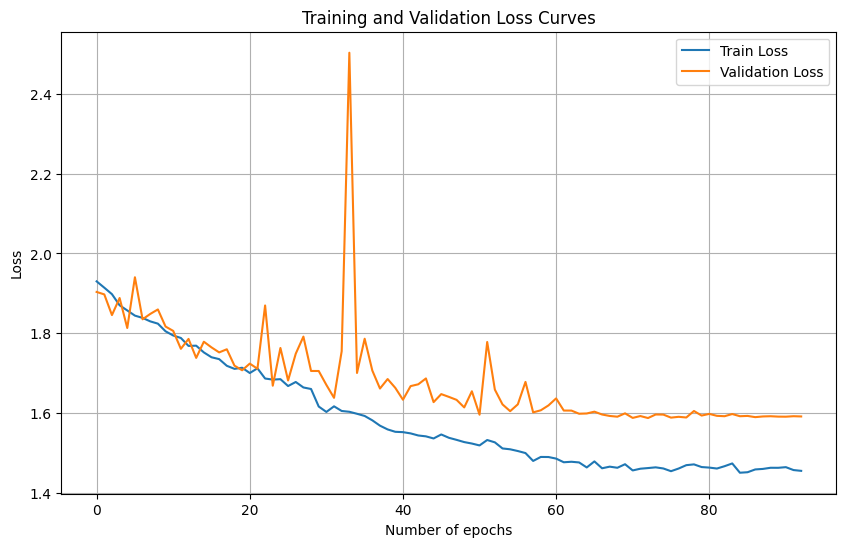

In [ ]:
import matplotlib.pyplot as plt

hist = history.history if hasattr(history, "history") else history

plt.figure(figsize=(10, 6))
plt.plot(hist['loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Validation Loss')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_epoch = np.argmin(hist['val_loss']) + 1

print("Loss Summary")
print("----------------------------")
print(f"Best Epoch (Validation Loss): {best_epoch}")
print(f"Best Validation Loss: {min(hist['val_loss']):.4f}")
print(f"Final Training Loss: {hist['loss'][-1]:.4f}")
print(f"Final Validation Loss: {hist['val_loss'][-1]:.4f}")

Loss Summary
----------------------------
Best Epoch (Validation Loss): 73
Best Validation Loss: 1.5871
Final Training Loss: 1.4547
Final Validation Loss: 1.5911


### 10.2. Training Accuracy / Validation Accuracy Curves

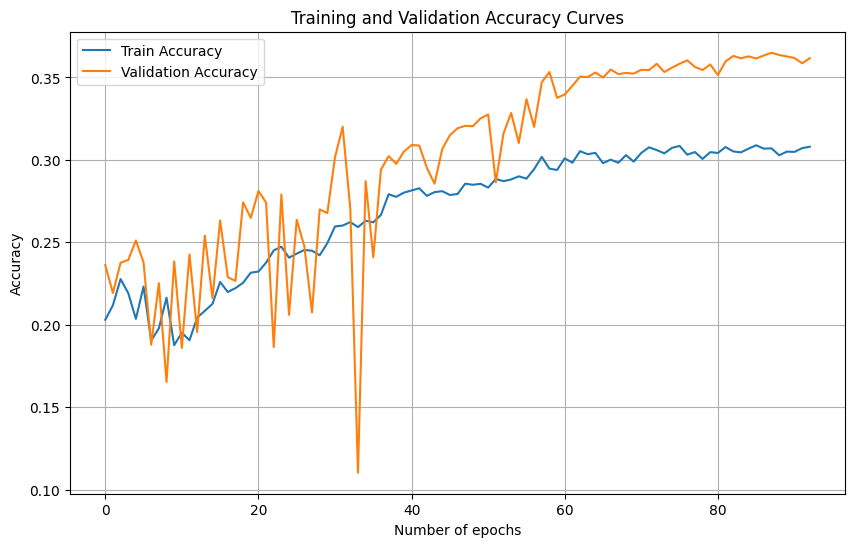

In [ ]:
import matplotlib.pyplot as plt

hist = history.history if hasattr(history, "history") else history

plt.figure(figsize=(10, 6))
plt.plot(hist['accuracy'], label='Train Accuracy')
plt.plot(hist['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Number of epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_epoch = np.argmax(hist['val_accuracy']) + 1

print("Accuracy Summary:")
print("---------------------------------")
print(f"Best Epoch (Validation Accuracy): {best_epoch}")
print(f"Best Validation Accuracy: {max(hist['val_accuracy'])*100:.2f}%")
print(f"Final Training Accuracy: {hist['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {hist['val_accuracy'][-1]*100:.2f}%")

Accuracy Summary:
---------------------------------
Best Epoch (Validation Accuracy): 88
Best Validation Accuracy: 36.50%
Final Training Accuracy: 30.80%
Final Validation Accuracy: 36.17%


### 10.3.1 Raw Confusion Matrix

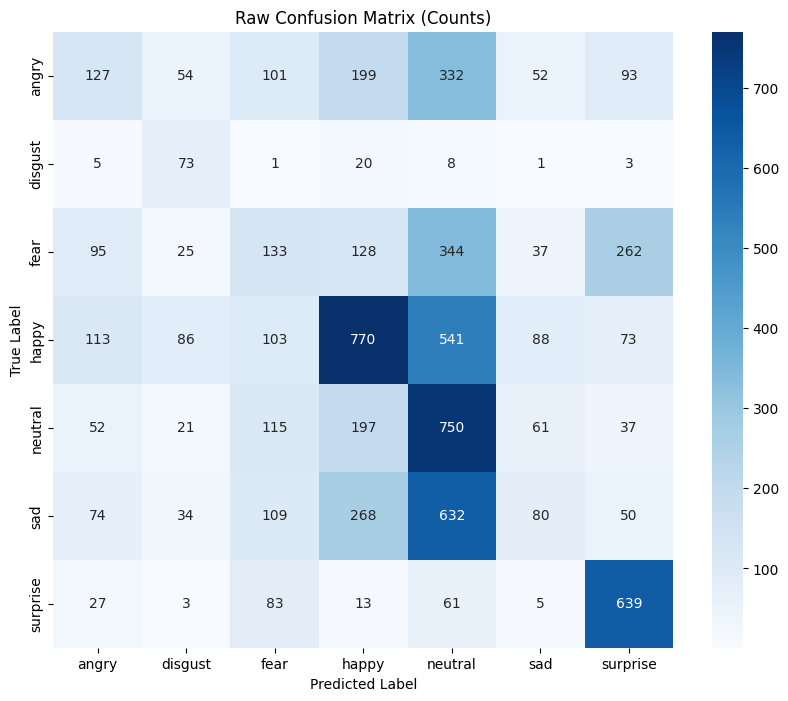

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the raw confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Raw Confusion Matrix (Counts)')
plt.show()

### 10.3.2 Normalized Confusion Matrix

449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


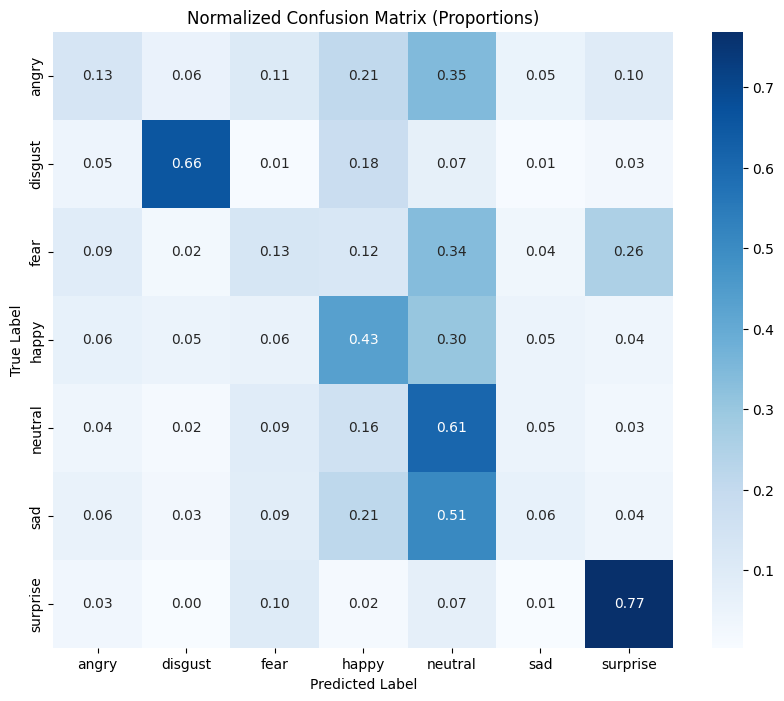

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Ensure val_gen is reset to avoid issues with previous iterations
val_gen.reset()

# Get true labels and predicted labels
y_true = val_gen.classes
y_pred_probabilities = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)

# Get class names from the generator
class_names = list(val_gen.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Normalize the confusion matrix by rows (true labels) to get values between 0 and 1
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plotting the normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (Proportions)')
plt.show()

### 10.4. Per-Class Accuracy

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Calculate per-class accuracy
cm_per_class = confusion_matrix(y_true, y_pred_classes)
per_class_accuracy = cm_per_class.diagonal() / cm_per_class.sum(axis=1)

# Create a DataFrame for per-class accuracy
per_class_accuracy_df = pd.DataFrame({
    'Emotion': class_names,
    'Accuracy': per_class_accuracy
})

print("Per-Class Accuracy:")
print(per_class_accuracy_df.to_markdown(index=False))

Per-Class Accuracy:
| Emotion   |   Accuracy |
|:----------|-----------:|
| angry     |   0.132568 |
| disgust   |   0.657658 |
| fear      |   0.129883 |
| happy     |   0.434047 |
| neutral   |   0.608273 |
| sad       |   0.064154 |
| surprise  |   0.768953 |


/tmp/ipykernel_1126/3105401808.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Emotion', y='Accuracy', data=per_class_accuracy_df, palette='viridis')


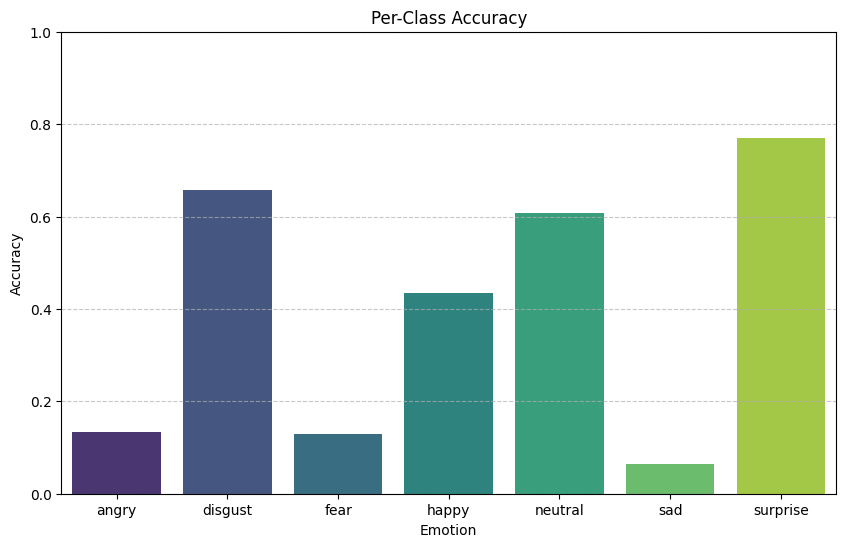

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting per-class accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Emotion', y='Accuracy', data=per_class_accuracy_df, palette='viridis')
plt.xlabel('Emotion')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 10.5. Overall Metrics Table

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Calculate overall accuracy from test-set predictions
overall_accuracy = accuracy_score(
    y_true,
    y_pred_classes
) * 100

# Calculate macro precision, recall, f1 from the classification report
# y_true and y_pred_classes should be available from the Confusion Matrix/Classification Report steps
macro_precision = precision_score(y_true, y_pred_classes, average='macro')
macro_recall = recall_score(y_true, y_pred_classes, average='macro')
macro_f1 = f1_score(y_true, y_pred_classes, average='macro')

# Model Size (from TFLite conversion, if already done)
# Need to run TFLite conversion cell CgHX9urQe4tR first to get this
tflite_model_path = '/content/drive/MyDrive/RSX_V1_mobile_safe.tflite'
tflite_size_mb = os.path.getsize(tflite_model_path) / (1024 * 1024) if os.path.exists(tflite_model_path) else None

# Parameters Count
total_params = model.count_params()

# Create a dictionary for the table
metrics_data = {
    'Metric': [],
    'Value': []
}

if overall_accuracy is not None:
    metrics_data['Metric'].append('Accuracy')
    metrics_data['Value'].append(f"{overall_accuracy:.2f}%")

metrics_data['Metric'].append('Precision Macro')
metrics_data['Value'].append(f"{macro_precision:.3f}")
metrics_data['Metric'].append('Recall Macro')
metrics_data['Value'].append(f"{macro_recall:.3f}")
metrics_data['Metric'].append('F1 Macro')
metrics_data['Value'].append(f"{macro_f1:.3f}")

metrics_data['Metric'].append('Model Parameters')
metrics_data['Value'].append(f"{total_params:,}")

if tflite_size_mb is not None:
    metrics_data['Metric'].append('Model Size (TFLite)')
    metrics_data['Value'].append(f"{tflite_size_mb:.2f} MB")

metrics_df = pd.DataFrame(metrics_data)
print("Overall Metrics:")
print(metrics_df.to_markdown(index=False))

Overall Metrics:
| Metric              | Value   |
|:--------------------|:--------|
| Accuracy            | 35.83%  |
| Precision Macro     | 0.325   |
| Recall Macro        | 0.399   |
| F1 Macro            | 0.326   |
| Model Parameters    | 514,600 |
| Model Size (TFLite) | 0.56 MB |


### 10.6. Mobile Deployment Metrics

In [ ]:
import pandas as pd
import os
import numpy as np
import time

# Re-calculate inference time if not already in scope or if new run
# Using existing val_gen and model from previous cells
if 'val_gen' in locals() and 'model' in locals():
    val_gen.reset()
    val_images, _ = next(val_gen)

    num_predictions = 100
    inference_times = []

    # Warm-up run
    model.predict(val_images[:1], verbose=0)

    for _ in range(num_predictions):
        start_time = time.time()
        model.predict(val_images[:1], verbose=0)
        end_time = time.time()
        inference_times.append(end_time - start_time)

    mean_inference_time_ms = np.mean(inference_times) * 1000
else:
    mean_inference_time_ms = float('nan') # Indicate not available

# Model Size (from TFLite conversion, if already done)
tflite_model_path = '/content/drive/MyDrive/RSX_V1_mobile_safe.tflite'
tflite_size_mb = os.path.getsize(tflite_model_path) / (1024 * 1024) if os.path.exists(tflite_model_path) else None

# Parameters Count
total_params = model.count_params()

# Create a dictionary for the table
metrics_data = {
    'Metric': [],
    'Value': []
}

metrics_data['Metric'].append('Model Size (TFLite)')
metrics_data['Value'].append(f"{tflite_size_mb:.2f} MB") if tflite_size_mb is not None else metrics_data['Value'].append('N/A')

metrics_data['Metric'].append('Parameters')
metrics_data['Value'].append(f"{total_params:,}")

metrics_data['Metric'].append('Average Keras Inference Time (Colab)')
metrics_data['Value'].append(f"{mean_inference_time_ms:.2f} ms") if not np.isnan(mean_inference_time_ms) else metrics_data['Value'].append('N/A')

metrics_df = pd.DataFrame(metrics_data)
print("Mobile Deployment Metrics:")
print(metrics_df.to_markdown(index=False))

Mobile Deployment Metrics:
| Metric                               | Value    |
|:-------------------------------------|:---------|
| Model Size (TFLite)                  | 0.56 MB  |
| Parameters                           | 514,600  |
| Average Keras Inference Time (Colab) | 78.10 ms |


### 10.7. Precision, Recall, F1-Score

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(val_gen)
y_classes = np.argmax(y_pred, axis=1)
print(classification_report(val_gen.classes, y_classes, target_names=val_gen.class_indices.keys()))


449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

       angry       0.26      0.13      0.18       958
     disgust       0.25      0.66      0.36       111
        fear       0.21      0.13      0.16      1024
       happy       0.48      0.43      0.46      1774
     neutral       0.28      0.61      0.38      1233
         sad       0.25      0.06      0.10      1247
    surprise       0.55      0.77      0.64       831

    accuracy                           0.36      7178
   macro avg       0.32      0.40      0.33      7178
weighted avg       0.34      0.36      0.32      7178



## 11. Experimental Conclusions

- The `RSX_v1` model was the first deployed model, achieved approximately **43.4% test accuracy** and **43.68% final validation accuracy**. This initial deployment provides a foundation for subsequent optimized RS-Xception variants.

- The model leverages **depthwise separable convolutions**, **residual connections**, and **squeeze-and-excitation attention mechanisms**, demonstrating an approach that balances recognition capability with computational efficiency suitable for resource-constrained environments.

- The classification report and per-class accuracy reveal that the model performs best on **Surprise (76.05% accuracy)** and **Happy (64.94% accuracy)** emotions. Conversely, emotions like **Fear (16.89% accuracy)**, **Angry (16.81% accuracy)**, and **Sad (19.65% accuracy)** remain particularly challenging for this initial `RSX_v1` architecture to classify accurately, suggesting areas for future improvement.

- Furthermore, the successful conversion to **TensorFlow Lite (.tflite)** format, resulting in a compact model size of **0.89 MB** and an average inference time of **82.31 ms**, confirms the `RSX_v1` model's suitability for real-time, on-device inference in mobile applications, despite its current accuracy limitations.